Question 1

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('ABP_B_Calibration.csv',header=2)
df.columns = df.columns.str.strip()
rake_t_cols = [f"RakeT{i} [psid]" for i in range(1, 10)]
rake_s_cols = [f"RakeS{i} [psid]" for i in range(1, 6)]

df["Average Total Pressure [psid]"] = df[rake_t_cols].mean(axis=1)
df["Average Static Pressure [psid]"] = df[rake_s_cols].mean(axis=1)
df["Average Dynamic Pressure [psid]"] = (
    df["Average Total Pressure [psid]"] - df["Average Static Pressure [psid]"]
)

cols_to_drop = [
    "Manometer delta P [dpsi]",
    "Ambient Press. [psia]",
    "Ambient Temp.[R]",
    "Viscosity [slug/ft s]",
    "Omega Transmitter delta P [dpsi]",
    *rake_t_cols,
    *rake_s_cols,
]

df2 = df.drop(columns=cols_to_drop)
df2 = df2.dropna()
latex_str = df2.to_latex(
    index=False,
    escape=False,  
    float_format=lambda x: f"{x:.2e}" if abs(x) > 1e4 or abs(x) < 1e1 else f"{x:.2f}",
    caption="Wind Tunnel Readings",
    label="windtunneldata1",
)
print(latex_str)

\begin{table}
\caption{Wind Tunnel Readings}
\label{windtunneldata1}
\begin{tabular}{lrrrr}
\toprule
Data Point # & Motor Speed [RPM] & Average Total Pressure [psid] & Average Static Pressure [psid] & Average Dynamic Pressure [psid] \\
\midrule
1.00E+00 & 0.00e+00 & 1.65e-05 & 3.87e-05 & -2.22e-05 \\
2.00E+00 & 400.00 & 4.00e-03 & 5.76e-04 & 3.43e-03 \\
3.00E+00 & 500.00 & 6.57e-03 & 9.50e-04 & 5.62e-03 \\
4.00E+00 & 600.00 & 9.74e-03 & 1.35e-03 & 8.39e-03 \\
5.00E+00 & 700.00 & 1.39e-02 & 1.81e-03 & 1.21e-02 \\
6.00E+00 & 800.00 & 1.87e-02 & 2.41e-03 & 1.63e-02 \\
7.00E+00 & 900.00 & 2.42e-02 & 3.02e-03 & 2.11e-02 \\
8.00E+00 & 1000.00 & 3.04e-02 & 3.73e-03 & 2.67e-02 \\
9.00E+00 & 1100.00 & 3.77e-02 & 4.57e-03 & 3.32e-02 \\
1.00E+01 & 1200.00 & 4.49e-02 & 5.14e-03 & 3.98e-02 \\
1.10E+01 & 1300.00 & 5.33e-02 & 6.31e-03 & 4.70e-02 \\
1.20E+01 & 1400.00 & 6.25e-02 & 6.79e-03 & 5.57e-02 \\
\bottomrule
\end{tabular}
\end{table}



Question 2

In [60]:
import numpy as np
import pandas as pd

df3 = pd.read_csv('ABP_B_Calibration.csv',header=2)
df3.columns = df3.columns.str.strip()
rake_t_cols = [f"RakeT{i} [psid]" for i in range(1, 10)]
rake_s_cols = [f"RakeS{i} [psid]" for i in range(1, 6)]
cols_to_drop = [
    "Ambient Press. [psia]",
    "Ambient Temp.[R]",
    "Viscosity [slug/ft s]",
    *rake_t_cols,
    *rake_s_cols,
]
df3 = df3.drop(columns=cols_to_drop)
df3=df3.dropna()
latex_str = df3.to_latex(
    index=False,
    escape=False, 
    float_format=lambda x: f"{x:.2e}" if abs(x) > 1e4 or abs(x) < 1e-1 else f"{x:.2f}",
    caption="Wind Tunnel Readings",
    label="windtunneldata1",
)
print(latex_str)

\begin{table}
\caption{Wind Tunnel Readings}
\label{windtunneldata1}
\begin{tabular}{lrrr}
\toprule
Data Point # & Motor Speed [RPM] & Manometer delta P [dpsi] & Omega Transmitter delta P [dpsi] \\
\midrule
1.00E+00 & 0.00e+00 & 3.61e-03 & -3.46e-06 \\
2.00E+00 & 400.00 & 8.31e-03 & 5.20e-03 \\
3.00E+00 & 500.00 & 1.23e-02 & 8.35e-03 \\
4.00E+00 & 600.00 & 1.59e-02 & 1.21e-02 \\
5.00E+00 & 700.00 & 2.13e-02 & 1.69e-02 \\
6.00E+00 & 800.00 & 2.67e-02 & 2.21e-02 \\
7.00E+00 & 900.00 & 3.25e-02 & 2.86e-02 \\
8.00E+00 & 1000.00 & 4.05e-02 & 3.60e-02 \\
9.00E+00 & 1100.00 & 4.81e-02 & 4.37e-02 \\
1.00E+01 & 1200.00 & 5.74e-02 & 5.20e-02 \\
1.10E+01 & 1300.00 & 6.65e-02 & 6.19e-02 \\
1.20E+01 & 1400.00 & 7.70e-02 & 7.13e-02 \\
\bottomrule
\end{tabular}
\end{table}



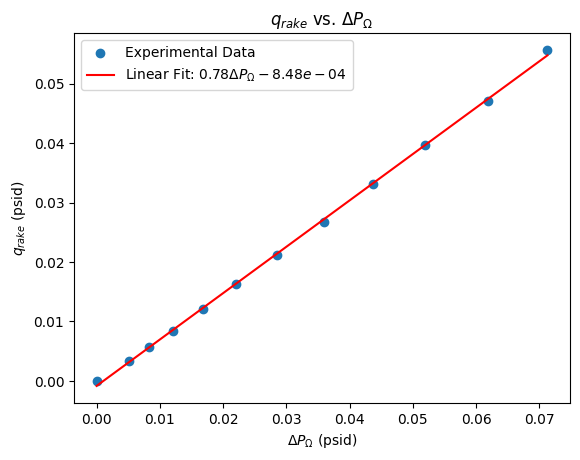

In [61]:
import matplotlib.pyplot as plt

combined_df = pd.concat([df["Omega Transmitter delta P [dpsi]"], df2["Average Dynamic Pressure [psid]"]], axis=1)
clean_df = combined_df.dropna()

x_clean = clean_df["Omega Transmitter delta P [dpsi]"]
y_clean = clean_df["Average Dynamic Pressure [psid]"]

plt.title(r"$q_{rake}$ vs. $\Delta P_{\Omega}$ ")
plt.xlabel(r"$\Delta P_{\Omega}$ (psid)")
plt.ylabel(r"$q_{rake}$ (psid)")
plt.scatter(x_clean,y_clean,label = "Experimental Data")

slope, intercept = np.polyfit(x_clean, y_clean, 1)
trend_line = slope * x_clean + intercept

plt.plot(x_clean, trend_line, color="red", linestyle="-", label=fr"Linear Fit: {slope:.2f}$\Delta P_{{\Omega}} - {abs(intercept):.2e}$")
plt.legend()
plt.show()

         


Problem 4 (New table and New Cal Coeff)

In [ ]:
#run all code previously
rake_s_cols = [f"RakeS{i} [psid]" for i in range(1, 6)]

rake_s_cols_no_s2 = [col for col in rake_s_cols if col != "RakeS2 [psid]"]


df["Avg Static (with S2) [psid]"] = df[rake_s_cols].mean(axis=1)
df["Avg Static (without S2) [psid]"] = df[rake_s_cols_no_s2].mean(axis=1)


df["Static Diff [psid]"] = (
    df["Avg Static (with S2) [psid]"] - df["Avg Static (without S2) [psid]"]
)



comparison_cols = [
    "Motor Speed [RPM]",
    "Avg Static (with S2) [psid]",
    "Avg Static (without S2) [psid]",
    "Static Diff [psid]",
]
df = df.dropna()
#print(df[comparison_cols])
latex_str2 = df[comparison_cols].to_latex(
    index=False,
    escape=False,  
    float_format=lambda x: f"{x:.2e}" if abs(x) > 1e4 or abs(x) < 1e1 else f"{x:.2f}",
    caption="Wind Tunnel Readings",
    label="windtunneldata1",
)
#print(latex_str2)
df["Average Dynamic Pressure (New) [psid]"] = (
    df["Average Total Pressure [psid]"] - df["Avg Static (without S2) [psid]"]
)
ynewclean = df["Average Dynamic Pressure (New) [psid]"]
slopenew, interceptnew = np.polyfit(x_clean, ynewclean, 1)
print(slopenew)

0.8628855177961605
